In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
scenario = 'bias_0.2_sd_0.0'
family = 'r5ad'

# Demand

In [74]:

forecast_df = pd.read_csv(f'/home/caio/Documents/tcc-caio/src/experiment/output/exec2_2023_spot/forecasts/demand_{scenario}.csv')
demand_df = pd.read_csv('/home/caio/Documents/tcc-caio/src/experiment/output/exec2_2023_spot/forecasts/demand_bias_0.0_sd_0.0.csv')

In [75]:
forecast_filt_df = forecast_df.filter(like=family, axis=1)
demand_filt_df = demand_df.filter(like=family, axis=1)

In [76]:
forecast_filt_df.head()

,r5ad.12xlarge,r5ad.2xlarge,r5ad.4xlarge,r5ad.8xlarge,r5ad.large,r5ad.xlarge
0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0


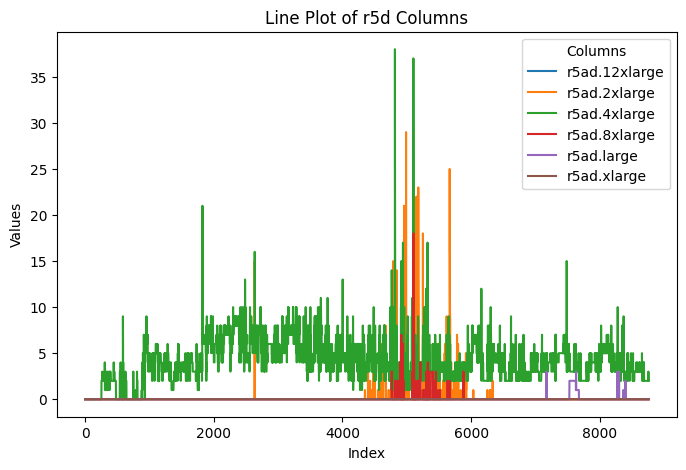

In [77]:
plt.figure(figsize=(8, 5))
for col in demand_filt_df.columns:
    plt.plot(demand_filt_df.index, demand_filt_df[col], label=col)

# Labels and title
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Line Plot of r5d Columns')

# Show legend with column names
plt.legend(title="Columns")

plt.show()

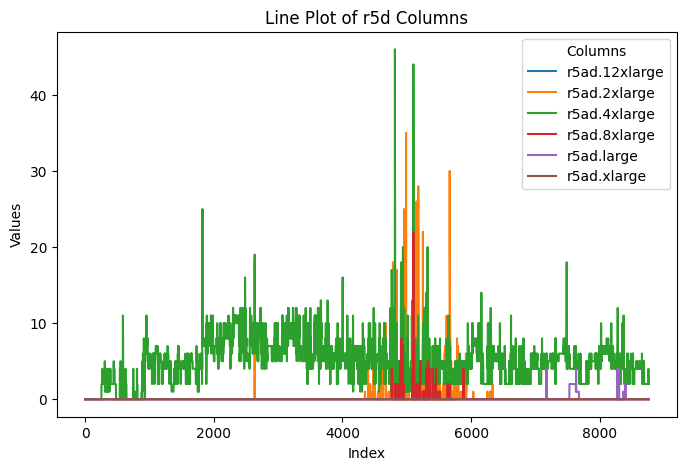

In [78]:
plt.figure(figsize=(8, 5))
for col in forecast_filt_df.columns:
    plt.plot(forecast_filt_df.index, forecast_filt_df[col], label=col)

# Labels and title
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Line Plot of r5d Columns')

# Show legend with column names
plt.legend(title="Columns")

plt.show()

In [79]:
plt.figure(figsize=(8, 5))
plt.plot(forecast_df.index, forecast_df[family], label='Forecast', marker='o')
plt.plot(demand_df.index, demand_df[family], label='Actual demand', marker='s')

# Labels and title
plt.xlabel('Index')
plt.ylabel('Family Values')
plt.title(f'Forecast vs actual demand ({family})')
plt.legend()

plt.show()

KeyError: 'r5ad'

<Figure size 800x500 with 0 Axes>

# Allocations

In [80]:
alloc_actual_df = pd.read_csv('/home/caio/Documents/tcc-caio/src/experiment/output/exec2_2023_spot/allocations/bias_0.0_sd_0.0/r5ad/alloc_cost.csv')
alloc_forecast_df = pd.read_csv('/home/caio/Documents/tcc-caio/src/experiment/output/exec2_2023_spot/allocations/bias_0.2_sd_0.0/r5ad/alloc_cost.csv')

alloc_inst_actual_df = pd.read_csv('/home/caio/Documents/tcc-caio/src/experiment/output/exec2_2023_spot/allocations/bias_0.0_sd_0.0/r5ad/alloc_instance.csv')
alloc_inst_forecast_df = pd.read_csv('/home/caio/Documents/tcc-caio/src/experiment/output/exec2_2023_spot/allocations/bias_0.2_sd_0.0/r5ad/alloc_instance.csv')

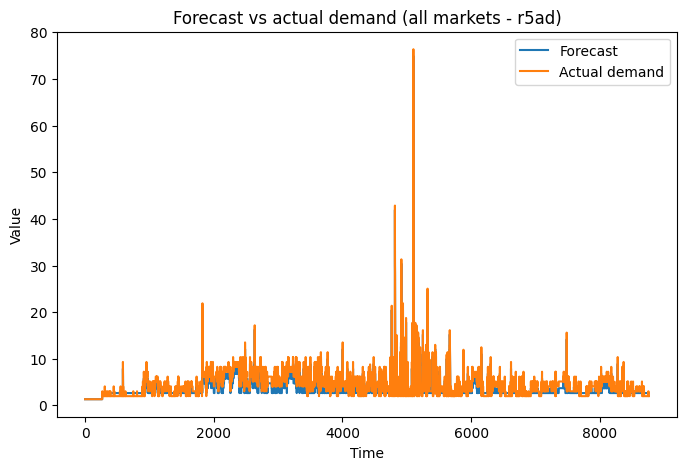

In [81]:
plt.figure(figsize=(8, 5))
plt.plot(alloc_forecast_df.index, alloc_forecast_df['AllMarkets'], label='Forecast')
plt.plot(alloc_actual_df.index, alloc_actual_df['AllMarkets'], label='Actual demand')

# Labels and title
plt.xlabel('Time')
plt.ylabel('Value')
plt.title(f'Forecast vs actual demand (all markets - {family})')
plt.legend()

plt.show()

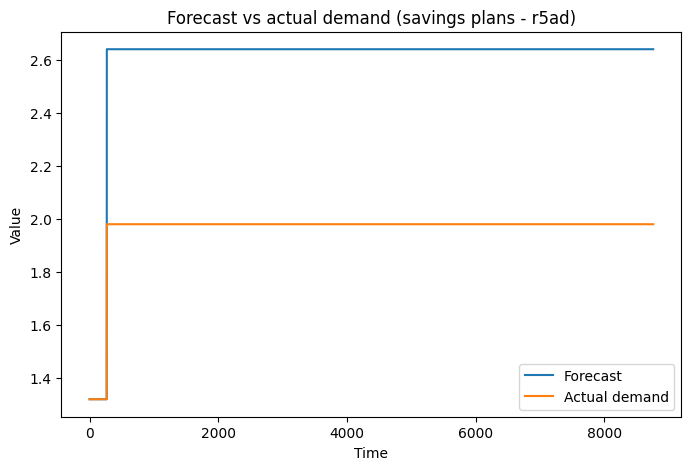

In [82]:
plt.figure(figsize=(8, 5))
plt.plot(alloc_forecast_df.index, alloc_forecast_df['RNo'], label='Forecast')
plt.plot(alloc_actual_df.index, alloc_actual_df['RNo'], label='Actual demand')

# Labels and title
plt.xlabel('Time')
plt.ylabel('Value')
plt.title(f'Forecast vs actual demand (savings plans - {family})')
plt.legend()

plt.show()

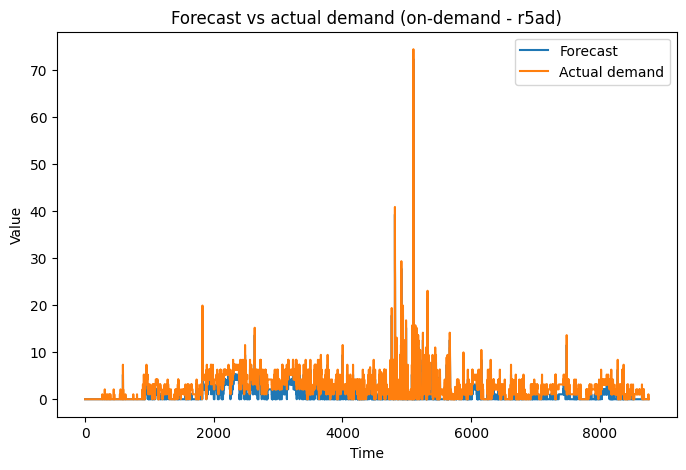

In [83]:
plt.figure(figsize=(8, 5))
plt.plot(alloc_forecast_df.index, alloc_forecast_df['OnDemand'], label='Forecast')
plt.plot(alloc_actual_df.index, alloc_actual_df['OnDemand'], label='Actual demand')

# Labels and title
plt.xlabel('Time')
plt.ylabel('Value')
plt.title(f'Forecast vs actual demand (on-demand - {family})')
plt.legend()

plt.show()

In [84]:
count = 0
max_diff = 0
t_max_diff = 0

for t in range(8760):
    cost_forecast = (alloc_forecast_df.iloc[t]['AllMarkets'])
    cost_actual = (alloc_actual_df.iloc[t]['AllMarkets'])

    if cost_actual > cost_forecast:
        diff = cost_actual - cost_forecast
        if diff > max_diff:
            max_diff = diff
            t_max_diff = t
        
        count += 1

print(count)

print(max_diff)
print(t_max_diff)
print('Aloc forecast')
print(alloc_forecast_df.iloc[t_max_diff])
print('Aloc actual')
print(alloc_actual_df.iloc[t_max_diff])


6560
1.436000000000007
5102
Aloc forecast
timestamp     5102.000
OnDemand        72.312
RAll             0.000
RPartialUp       0.000
RPartialHr       0.000
RNo              2.640
AllMarkets      74.952
Name: 5102, dtype: float64
Aloc actual
timestamp     5102.000
OnDemand        74.408
RAll             0.000
RPartialUp       0.000
RPartialHr       0.000
RNo              1.980
AllMarkets      76.388
Name: 5102, dtype: float64


In [85]:
print('Aloc forecast')
print(alloc_inst_forecast_df.loc[alloc_inst_forecast_df['timestamp'] == t_max_diff, ['market', 'r5ad.4xlarge', 'r5ad.8xlarge']])
print('Aloc actual')
print(alloc_inst_actual_df.loc[alloc_inst_actual_df['timestamp'] == t_max_diff, ['market', 'r5ad.4xlarge', 'r5ad.8xlarge']])

Aloc forecast
          market  r5ad.4xlarge  r5ad.8xlarge
20408  on_demand          37.0          16.0
20409      r_all           0.0           0.0
20410  r_partial           0.0           0.0
20411       r_no           0.0           2.0
Aloc actual
          market  r5ad.4xlarge  r5ad.8xlarge
20408  on_demand          37.0          17.0
20409      r_all           0.0           0.0
20410  r_partial           0.0           0.0
20411       r_no           0.0           1.0


In [86]:
print('actual ondemand:', sum(alloc_actual_df['OnDemand']))
print('actual sp:', sum(alloc_actual_df['RNo']))
print('actual all:', sum(alloc_actual_df['AllMarkets']))
print('forecast ondemand:', sum(alloc_forecast_df['OnDemand']))
print('forecast sp:', sum(alloc_forecast_df['RNo']))
print('forecast all:', sum(alloc_forecast_df['AllMarkets']))

actual ondemand: 19553.584000000003
actual sp: 17168.579999999998
actual all: 36722.164000000004
forecast ondemand: 7889.082
forecast sp: 22773.960000000003
forecast all: 30663.042


# Optimal

In [87]:
result_opt = pd.read_csv('/home/caio/Documents/tcc-caio/src/experiment/output/exec2_2023_spot/optimizations/bias_0.0_sd_0.0/r5ad/output/result_cost.csv')
opt_sp_purchases = pd.read_csv('/home/caio/Documents/tcc-caio/src/experiment/output/exec2_2023_spot/optimizations/bias_0.0_sd_0.0/r5ad/output/total_purchases_savings_plan.csv')

In [88]:
opt_sp_purchases.head()

,hour,market,value_active,value_reserves
0,1672531200,savings_plan,1.32,1.32
1,1672534800,savings_plan,1.32,0.00
2,1672538400,savings_plan,1.32,0.00
3,1672542000,savings_plan,1.32,0.00
4,1672545600,savings_plan,1.32,0.00


In [89]:
sum(opt_sp_purchases['value_active'])

17168.579999999998

In [ ]:
sum(opt_sp_purchases['value_reserves']) * 8760

17344.8

In [91]:
result_opt

,instance,total_cost
0,all,30253.802
1,savings_plan,17344.800
2,r5ad.12xlarge,0.000
3,r5ad.2xlarge,763.468
4,r5ad.4xlarge,11865.456
5,r5ad.8xlarge,245.232
6,r5ad.large,34.846
7,r5ad.xlarge,0.000


A diferença de custos (a compra de sp com forecast ser melhor do que com a demanda real) pode ser justificada pelas reservas de savings plans no futuro. O otimizador considera, no cálculo do custo e escolha da configuração de mercados, os savings plans que estão ativos após o final do período considerado (por ex, savings plans que estão ativos no início de 2024, em uma otimização para 2023). Por outro lado, o custo retornado pelo alocador não incluí esses savings plans, já que ele retorna os custos em cada hora do intervalo considerado.

Assim, uma compra maior de savings plans (feita por causa dos forecasts) pode acabar saindo mais barata quando observamos os resultados do alocador. Essa compra mais alta gera mais disperdício após o final do intervalo do que a compra ótima e, por esse desperdício não estar sendo considerado, a compra com forecast pode ficar mais barata.

# Savings Plans Purchases

Comparando as compras de savings plans feitas pelo otimizador a partir da demanda real e da previsão. O objetivo é entender a magnitude das reservas de savings plans que estão sobrando após o final do intervalo.

In [93]:
total_sp_value_opt = sum(opt_sp_purchases['value_reserves'])*8760
print(total_sp_value_opt)

17344.8


In [99]:
forecast_result_cost = pd.read_csv(f'/home/caio/Documents/tcc-caio/src/experiment/output/exec2_2023_spot/optimizations/{scenario}/r5ad/output/result_cost.csv')
forecast_result_cost

,instance,total_cost
0,all,36694.594
1,savings_plan,23126.400
2,r5ad.12xlarge,0.000
3,r5ad.2xlarge,878.224
4,r5ad.4xlarge,12400.984
5,r5ad.8xlarge,253.616
6,r5ad.large,35.370
7,r5ad.xlarge,0.000


In [94]:
forecast_sp_purchases = pd.read_csv(f'/home/caio/Documents/tcc-caio/src/experiment/output/exec2_2023_spot/optimizations/{scenario}/r5ad/output/total_purchases_savings_plan.csv')
total_sp_value_forecast = sum(forecast_sp_purchases['value_reserves'])*8760
print(total_sp_value_forecast)

23126.4


In [96]:
total_cost_opt = total_sp_value_opt + 19553.584
print(total_cost_opt)

36898.384


In [97]:
total_cost_forecast = total_sp_value_forecast + 7889.082
print(total_cost_forecast)

31015.482000000004


In [98]:
total_cost_forecast/total_cost_opt

0.8405647792055068